# Librerías

In [2]:
import pandas as pd
import numpy as np
import time
import requests
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Descarga de datos

In [6]:
base_url = "https://www.datos.gov.co/resource/u37r-hjmu.csv"

chunks = []
limit = 50000  # más seguro que 100k

headers = {
    "User-Agent": "Mozilla/5.0"
}

for offset in range(0, 1300000, limit):
    url = f"{base_url}?$limit={limit}&$offset={offset}"
    print(f"Descargando offset {offset}...")

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print(f"Error en offset {offset}: {response.status_code}")
        break

    data = StringIO(response.text)
    chunk = pd.read_csv(data)

    if chunk.shape[0] == 0:
        break

    chunks.append(chunk)

    time.sleep(2)  # clave para evitar bloqueo

df = pd.concat(chunks, ignore_index=True)

print(df.shape)

Descargando offset 0...
Descargando offset 50000...
Descargando offset 100000...
Descargando offset 150000...
Descargando offset 200000...
Descargando offset 250000...
Descargando offset 300000...
Descargando offset 350000...
Descargando offset 400000...
Descargando offset 450000...
Descargando offset 500000...
Descargando offset 550000...
Descargando offset 600000...
Descargando offset 650000...
Descargando offset 700000...


C:\Users\Dante_RT\AppData\Local\Temp\ipykernel_24232\1812025102.py:21: DtypeWarning: Columns (0: estu_cole_termino) have mixed types. Specify dtype option on import or set low_memory=False.
  chunk = pd.read_csv(data)


Descargando offset 750000...
Descargando offset 800000...
Descargando offset 850000...
Descargando offset 900000...
Descargando offset 950000...
Descargando offset 1000000...
Descargando offset 1050000...
Descargando offset 1100000...
Descargando offset 1150000...
Descargando offset 1200000...
Descargando offset 1250000...
(1217482, 57)


In [8]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("string")

C:\Users\Dante_RT\AppData\Local\Temp\ipykernel_24232\3185290847.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [3]:
# df.to_parquet(
#     r'C:\Users\Dante_RT\Downloads\Proyecto_prob\data\rawcSaber_Pro\saberpro_full.parquet',
#     engine="pyarrow",
#     index=False
# )

df = pd.read_parquet(r'C:\Users\Dante_RT\Downloads\Proyecto_prob\data\raw\Saber_Pro\saberpro_full.parquet')

# Exploración de datos

In [12]:
df.shape

(1217482, 57)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1217482 entries, 0 to 1217481
Data columns (total 57 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   periodo                         1217482 non-null  int64  
 1   estu_consecutivo                1217482 non-null  string 
 2   estu_tipodocumento              1217482 non-null  string 
 3   estu_pais_reside                1217482 non-null  string 
 4   estu_cod_reside_depto           1214089 non-null  float64
 5   estu_depto_reside               1214089 non-null  string 
 6   estu_cod_reside_mcpio           1214089 non-null  float64
 7   estu_mcpio_reside               1214089 non-null  string 
 8   estu_coddane_cole_termino       817440 non-null   float64
 9   estu_cod_cole_mcpio_termino     817440 non-null   float64
 10  estu_cod_depto_presentacion     1217378 non-null  float64
 11  inst_cod_institucion            1217482 non-null  int64  
 12  inst_nombre

In [27]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df.head()

,PERIODO,ESTU_CONSECUTIVO,ESTU_TIPODOCUMENTO,ESTU_PAIS_RESIDE,ESTU_COD_RESIDE_DEPTO,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_MCPIO,ESTU_MCPIO_RESIDE,ESTU_CODDANE_COLE_TERMINO,ESTU_COD_COLE_MCPIO_TERMINO,ESTU_COD_DEPTO_PRESENTACION,INST_COD_INSTITUCION,INST_NOMBRE_INSTITUCION,INST_CARACTER_ACADEMICO,ESTU_NUCLEO_PREGRADO,ESTU_INST_DEPARTAMENTO,ESTU_INST_CODMUNICIPIO,ESTU_INST_MUNICIPIO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_PRGM_CODMUNICIPIO,ESTU_PRGM_MUNICIPIO,ESTU_NIVEL_PRGM_ACADEMICO,ESTU_METODO_PRGM,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_DEPTO_PRESENTACION,ESTU_COD_MCPIO_PRESENTACION,ESTU_MCPIO_PRESENTACION,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_SNIES_PRGMACADEMICO,ESTU_PRIVADO_LIBERTAD,ESTU_NACIONALIDAD,ESTU_ESTUDIANTE,ESTU_GENERO,ESTU_COLE_TERMINO,ESTU_PAGOMATRICULAPADRES,ESTU_ESTADOINVESTIGACION,ESTU_FECHANACIMIENTO,ESTU_PAGOMATRICULAPROPIO,ESTU_TIPODOCUMENTOSB11,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,INST_ORIGEN,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_COMUNI_ESCRITA_DESEM,MOD_INGLES_DESEM,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
0,20183,EK201830011083,CC,COLOMBIA,11.0,BOGOTÁ,11001.0,BOGOTÁ D.C.,NaN,NaN,11.0,2834,UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,BOGOTÁ,11001,BOGOTÁ D.C.,HOTELERIA Y TURISMO,BOGOTÁ,11001,BOGOTÁ D.C.,UNIVERSITARIO,PRESENCIAL,Entre 2.5 millones y menos de 4 millones,BOGOTÁ,11001.0,BOGOTÁ D.C.,No,No,Entre 11 y 20 horas,54487.0,N,COLOMBIA,ESTUDIANTE,F,<NA>,Si,PUBLICAR,18/09/1997,No,CC,Primaria completa,Si,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,NO OFICIAL - CORPORACIÓN,161,174.0,3.0,A2,139,161.0,128
1,20183,EK201830053875,CC,COLOMBIA,76.0,VALLE,76736.0,SEVILLA,NaN,NaN,76.0,1203,UNIVERSIDAD DEL VALLE-CALI,UNIVERSIDAD,CONTADURÍA PUBLICA,VALLE,76001,CALI,CONTADURIA PUBLICA,VALLE,76834,TULUÁ,UNIVERSITARIO,PRESENCIAL,Menos de 500 mil,VALLE,76834.0,TULUÁ,No,No,Entre 21 y 30 horas,52346.0,N,COLOMBIA,ESTUDIANTE,M,<NA>,Si,PUBLICAR,24/07/1995,No,TI,Primaria incompleta,No,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,OFICIAL DEPARTAMENTAL,147,170.0,3.0,B1,171,188.0,182
2,20183,EK201830167993,CC,COLOMBIA,73.0,TOLIMA,73001.0,IBAGUÉ,1.730010e+11,73001.0,73.0,2829,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIMINUTO-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,CONTADURÍA PUBLICA,BOGOTÁ,11001,BOGOTÁ D.C.,CONTADURÍA PÚBLICA,BOGOTÁ,11001,BOGOTÁ D.C.,UNIVERSITARIO,DISTANCIA,Entre 1 millón y menos de 2.5 millones,TOLIMA,73001.0,IBAGUÉ,No,No,Más de 30 horas,91334.0,N,COLOMBIA,ESTUDIANTE,M,SEDE 1 GERMAN PARDO,No,PUBLICAR,18/03/1994,Si,CC,No Aplica,No,Si,Estrato 2,Si,Si,No sabe,NO OFICIAL - CORPORACIÓN,142,77.0,1.0,A1,124,130.0,153
3,20183,EK201830168158,CC,COLOMBIA,68.0,SANTANDER,68081.0,BARRANCABERMEJA,1.680810e+11,68081.0,68.0,2207,INSTITUTO UNIVERSITARIO DE LA PAZ-BARRANCABERMEJA,INSTITUCIÓN UNIVERSITARIA,"INGENIERÍA AMBIENTAL, SANITARIA Y AFINES",SANTANDER,68081,BARRANCABERMEJA,INGENIERIA AMBIENTAL Y DE SANEAMIENTO,SANTANDER,68081,BARRANCABERMEJA,UNIVERSITARIO,PRESENCIAL,Entre 500 mil y menos de 1 millón,SANTANDER,68081.0,BARRANCABERMEJA,No,No,0,3127.0,N,COLOMBIA,ESTUDIANTE,M,INSTITUTO TECNICO INDUSTRIAL,Si,PUBLICAR,29/06/1997,No,TI,Postgrado,No,Si,Estrato 2,Si,Si,Técnica o tecnológica completa,OFICIAL DEPARTAMENTAL,185,157.0,3.0,-A1,178,106.0,169
4,20183,EK201830164354,CC,COLOMBIA,11.0,BOGOTÁ,11001.0,BOGOTÁ D.C.,1.110010e+11,11001.0,11.0,1208,UNIVERSIDAD DEL QUINDIO-ARMENIA,UNIVERSIDAD,"BIBLIOTECOLOGÍA, OTROS DE CIENCIAS SOCIALES Y HUMANAS",QUINDIO,63001,ARMENIA,CIENCIAS DE LA INFORMACION Y LA DOCUMENTACION,QUINDIO,63001,ARMENIA,UNIVERSITARIO,DISTANCIA VITUAL,Entre 500 mil y menos de 1 millón,BOGOTÁ,11001.0,BOGOTÁ D.C.,No,No,Entre 21 y 30 horas,833.0,N,COLOMBIA,ESTUDIANTE,F,CENT EDUC DIST NUEVA CONSTITUCION,No,PUBLICAR,23/09/1987,Si,TI,Educación profesional completa,No,Si,E

In [12]:
df.columns.tolist()

['periodo',
 'estu_consecutivo',
 'estu_tipodocumento',
 'estu_pais_reside',
 'estu_cod_reside_depto',
 'estu_depto_reside',
 'estu_cod_reside_mcpio',
 'estu_mcpio_reside',
 'estu_coddane_cole_termino',
 'estu_cod_cole_mcpio_termino',
 'estu_cod_depto_presentacion',
 'inst_cod_institucion',
 'inst_nombre_institucion',
 'inst_caracter_academico',
 'estu_nucleo_pregrado',
 'estu_inst_departamento',
 'estu_inst_codmunicipio',
 'estu_inst_municipio',
 'estu_prgm_academico',
 'estu_prgm_departamento',
 'estu_prgm_codmunicipio',
 'estu_prgm_municipio',
 'estu_nivel_prgm_academico',
 'estu_metodo_prgm',
 'estu_valormatriculauniversidad',
 'estu_depto_presentacion',
 'estu_cod_mcpio_presentacion',
 'estu_mcpio_presentacion',
 'estu_pagomatriculabeca',
 'estu_pagomatriculacredito',
 'estu_horassemanatrabaja',
 'estu_snies_prgmacademico',
 'estu_privado_libertad',
 'estu_nacionalidad',
 'estu_estudiante',
 'estu_genero',
 'estu_cole_termino',
 'estu_pagomatriculapadres',
 'estu_estadoinvestigaci

# Descripcion de los datos:

Nombre de la columna
Descripción

Nombre del campo API

PERIODO - Periodo de los resultados - periodo - Texto
ESTU_CONSECUTIVO - Identificador del examinando
estu_consecutivo
Texto
ESTU_TIPODOCUMENTO
Tipo de documento
estu_tipodocumento
Texto
ESTU_PAIS_RESIDE
País de residencia del examinando
estu_pais_reside
Texto
ESTU_COD_RESIDE_DEPTO
Código Departamento de residencia del examinando
estu_cod_reside_depto
Texto
ESTU_DEPTO_RESIDE
Departamento de residencia del examinando
estu_depto_reside
Texto
ESTU_COD_RESIDE_MCPIO
Código del municipio donde reside
estu_cod_reside_mcpio
Texto
ESTU_MCPIO_RESIDE
Municipio donde reside el examinando
estu_mcpio_reside
Texto
ESTU_CODDANE_COLE_TERMINO
Código Dane del Colegio donde se graduó.
estu_coddane_cole_termino
Texto
ESTU_COD_COLE_MCPIO_TERMINO
Municipio donde termino bachillerato
estu_cod_cole_mcpio_termino
Texto
ESTU_COD_DEPTO_PRESENTACION
Código Departamento de Presentación del examen.
estu_cod_depto_presentacion
Texto
INST_COD_INSTITUCION
Código de la institución Educación Superior
inst_cod_institucion
Texto
INST_NOMBRE_INSTITUCION
Nombre Institución de Educación Superior
inst_nombre_institucion
Texto
INST_CARACTER_ACADEMICO
Carácter Académico Institución.
inst_caracter_academico
Texto
ESTU_NUCLEO_PREGRADO
Núcleo asociado al pregrado que estudia.
estu_nucleo_pregrado
Texto
ESTU_INST_DEPARTAMENTO
Departamento de la Institución Educación Superior
estu_inst_departamento
Texto
ESTU_INST_CODMUNICIPIO
Código del municipio de la Institución Educación Superior
estu_inst_codmunicipio
Texto
ESTU_INST_MUNICIPIO
Municipio de la Institución Educación Superior
estu_inst_municipio
Texto
ESTU_PRGM_ACADEMICO
Programa académico al que pertenece
estu_prgm_academico
Texto
ESTU_PRGM_DEPARTAMENTO
Departamento del programa académico.
estu_prgm_departamento
Texto
ESTU_PRGM_CODMUNICIPIO
Código del municipio del programa académico
estu_prgm_codmunicipio
Texto
ESTU_PRGM_MUNICIPIO
Municipio del programa académico.
estu_prgm_municipio
Texto
ESTU_NIVEL_PRGM_ACADEMICO
Nivel del programa académico
estu_nivel_prgm_academico
Texto
ESTU_METODO_PRGM
Metodología del programa académico
estu_metodo_prgm
Texto
ESTU_VALORMATRICULAUNIVERSIDAD
Valor matricula de la universidad
estu_valormatriculauniversidad
Texto
ESTU_DEPTO_PRESENTACION
Departamento de Presentación del examen.
estu_depto_presentacion
Texto
ESTU_COD_MCPIO_PRESENTACION
Código de Municipio de Presentación del examen.
estu_cod_mcpio_presentacion
Texto
ESTU_MCPIO_PRESENTACION
Municipio de Presentación del examen.
estu_mcpio_presentacion
Texto
ESTU_PAGOMATRICULABECA
¿Paga usted mismo su matricula?
estu_pagomatriculabeca
Texto
ESTU_PAGOMATRICULACREDITO
¿Tiene crédito para pagar su matricula?
estu_pagomatriculacredito
Texto
ESTU_HORASSEMANATRABAJA
¿Cuántas horas a las semana trabaja?
estu_horassemanatrabaja
Texto
ESTU_SNIES_PRGMACADEMICO
Código Snies del Programa Académico
estu_snies_prgmacademico
Texto
ESTU_PRIVADO_LIBERTAD
¿Es privado de la libertad?
estu_privado_libertad
Texto
ESTU_NACIONALIDAD
Nacionalidad del examinando
estu_nacionalidad
Texto
ESTU_ESTUDIANTE
S si es estudiante o N si es individual
estu_estudiante
Texto
ESTU_GENERO
Genero del examinando
estu_genero
Texto
ESTU_COLE_TERMINO
Colegio donde termino bachillerato
estu_cole_termino
Texto
ESTU_PAGOMATRICULAPADRES
¿Sus padres pagan su matricula?
estu_pagomatriculapadres
Texto
ESTU_ESTADOINVESTIGACION
¿Permite publicar la investigación?
estu_estadoinvestigacion
Texto
ESTU_FECHANACIMIENTO
Fecha de nacimiento del examinando
estu_fechanacimiento
Texto
ESTU_PAGOMATRICULAPROPIO
¿Paga usted mismo su matricula?
estu_pagomatriculapropio
Texto
ESTU_TIPODOCUMENTOSB11
Tipo de documento con el que presento Saber 11
estu_tipodocumentosb11
Texto
FAMI_EDUCACIONPADRE
Nivel de estudios del padre
fami_educacionpadre
Texto
FAMI_TIENEAUTOMOVIL
¿Tiene automóvil?
fami_tieneautomovil
Texto
FAMI_TIENELAVADORA
¿Tiene lavadora?
fami_tienelavadora
Texto
FAMI_ESTRATOVIVIENDA
Estrato del examinando
fami_estratovivienda
Texto
FAMI_TIENECOMPUTADOR
¿Tiene computador?
fami_tienecomputador
Texto
FAMI_TIENEINTERNET
¿Tiene internet?
fami_tieneinternet
Texto
FAMI_EDUCACIONMADRE
Nivel de estudios de la madre
fami_educacionmadre
Texto
INST_ORIGEN
Tipo de Institución en la que Estudia
inst_origen
Texto
MOD_RAZONA_CUANTITAT_PUNT
Puntaje Modulo Razonamiento Cuantitativo
mod_razona_cuantitat_punt
Texto
MOD_COMUNI_ESCRITA_PUNT
Puntaje Modulo Comunicación Escrita
mod_comuni_escrita_punt
Texto
MOD_COMUNI_ESCRITA_DESEM
Desempeño Modulo comunicación escrita
mod_comuni_escrita_desem
Texto
MOD_INGLES_DESEM
Desempeño modulo de Inglés
mod_ingles_desem
Texto
MOD_LECTURA_CRITICA_PUNT
Puntaje Modulo Lectura Crítica
mod_lectura_critica_punt
Texto
MOD_INGLES_PUNT
Puntaje Modulo Inglés
mod_ingles_punt
Texto
MOD_COMPETEN_CIUDADA_PUNT
Puntaje Modulo Competencias Ciudadanas
mod_competen_ciudada_punt
Texto

In [4]:
# Normalizamos nombres de clumnas
df.columns = df.columns.str.strip().str.lower()

In [29]:
# Ver las carreras únicas
df["estu_prgm_academico"].unique()

<ArrowStringArray>
[                              'HOTELERIA Y TURISMO',
                                'CONTADURIA PUBLICA',
                                'CONTADURÍA PÚBLICA',
             'INGENIERIA AMBIENTAL Y DE SANEAMIENTO',
     'CIENCIAS DE LA INFORMACION Y LA DOCUMENTACION',
                                        'PSICOLOGIA',
                        'ADMINISTRACION DE EMPRESAS',
                          'NEGOCIOS INTERNACIONALES',
                        'ADMINISTRACIÓN DE EMPRESAS',
                            'INGENIERIA INFORMATICA',
 ...
                               'INGENIERIA ACUICOLA',
                     'CIENCIAS POLÍTICAS Y GOBIERNO',
 'INGENIERÍA EN PROCESOS SOSTENIBLES DE LAS MADERAS',
                           'INGENIERÍA EN LOGÍSTICA',
                           'INGENIERÍA AGROFORESTAL',
               'LICENCIATURA EN EDUCACIÓN RELIGIOSA',
     'LICENCIATURA EN ESPA¿OL Y LENGUAS EXTRANJERAS',
             'LICENCIATURA EN RECREACIÓN  Y TURISMO',
    

In [31]:
df["estu_nucleo_pregrado"].value_counts()

estu_nucleo_pregrado
ADMINISTRACIÓN                                           251455
EDUCACIÓN                                                111636
DERECHO Y AFINES                                          97009
CONTADURÍA PUBLICA                                        90022
PSICOLOGÍA                                                86856
INGENIERÍA INDUSTRIAL Y AFINES                            65767
INGENIERÍA DE SISTEMAS, TELEMÁTICA Y AFINES               45972
INGENIERÍA CIVIL Y AFINES                                 40238
MEDICINA                                                  33569
SOCIOLOGÍA, TRABAJO SOCIAL Y AFINES                       32670
COMUNICACIÓN SOCIAL, PERIODISMO Y AFINES                  30877
INGENIERÍA AMBIENTAL, SANITARIA Y AFINES                  26418
ARQUITECTURA                                              26201
ECONOMÍA                                                  25089
ENFERMERÍA                                                21395
INGENIERÍA MECÁNICA

# Filtrado de datos

In [5]:
# Filtrar ingeniería en sistemas
df_sistemas = df[
    df["estu_prgm_academico"].str.contains("sistemas", case=False, na=False)
]

In [6]:
df_sistemas.info()

<class 'pandas.DataFrame'>
Index: 38109 entries, 33 to 1217431
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   periodo                         38109 non-null  int64  
 1   estu_consecutivo                38109 non-null  string 
 2   estu_tipodocumento              38109 non-null  string 
 3   estu_pais_reside                38109 non-null  string 
 4   estu_cod_reside_depto           37999 non-null  float64
 5   estu_depto_reside               37999 non-null  string 
 6   estu_cod_reside_mcpio           37999 non-null  float64
 7   estu_mcpio_reside               37999 non-null  string 
 8   estu_coddane_cole_termino       27486 non-null  float64
 9   estu_cod_cole_mcpio_termino     27486 non-null  float64
 10  estu_cod_depto_presentacion     38108 non-null  float64
 11  inst_cod_institucion            38109 non-null  int64  
 12  inst_nombre_institucion         38109 non-nul

In [7]:
# ── Columnas a ELIMINAR (no aportan a la predicción) ──────────────────────────
drop_cols = [
    # Identificadores únicos — nunca usar como features
    "estu_consecutivo",
    "estu_tipodocumento",
    "estu_tipodocumentosb11",

    # Administrativa/geográfica redundante o de baja señal
    "estu_coddane_cole_termino",       # código DANE del colegio (muy granular, poco signal)
    "estu_cod_cole_mcpio_termino",
    "estu_cod_reside_depto",           # código numérico — ya tenemos nombre del depto
    "estu_cod_reside_mcpio",
    "estu_cod_depto_presentacion",
    "estu_cod_mcpio_presentacion",
    "estu_inst_codmunicipio",
    "estu_prgm_codmunicipio",
    "estu_snies_prgmacademico",        # código SNIES — reemplazado por nombre del programa
    "inst_cod_institucion",            # código numérico de institución

    # Variables constantes para este subconjunto filtrado
    "estu_nucleo_pregrado",            # todos son ingeniería → constante o casi
    "estu_prgm_academico",             # ya filtramos, es constante
    "estu_nivel_prgm_academico",       # pregrado → constante
    "estu_pais_reside",                # casi todos Colombia
    "estu_privado_libertad",           # casi todo "No"
    "estu_estudiante",                 # casi todo "S"
    "estu_nacionalidad",               # casi todo Colombia
    "estu_estadoinvestigacion",        # permiso de publicación, no predictivo

    # Fechas crudas difíciles de usar directamente
    "estu_fechanacimiento",            # → se puede derivar edad si se quiere, pero opcional
]

# ── Columnas a CONSERVAR ───────────────────────────────────────────────────────
# Socioeconómicas (features principales del paper)
socioeconomicas = [
    "fami_estratovivienda",
    "fami_educacionpadre",
    "fami_educacionmadre",
    "fami_tieneautomovil",
    "fami_tienelavadora",
    "fami_tienecomputador",
    "fami_tieneinternet",
    "estu_horassemanatrabaja",
    "estu_valormatriculauniversidad",
    "estu_pagomatriculabeca",
    "estu_pagomatriculacredito",
    "estu_pagomatriculapadres",
    "estu_pagomatriculapropio",
]

# Institucionales / académicas
institucionales = [
    "inst_nombre_institucion",         # calidad de la universidad — importante
    "inst_caracter_academico",         # universidad, tecnológica, etc.
    "inst_origen",                     # pública / privada
    "estu_metodo_prgm",                # presencial, distancia, virtual
    "estu_prgm_departamento",
]

# Demográficas
demograficas = [
    "estu_genero",
    "estu_depto_reside",
    "estu_mcpio_reside",
    "estu_depto_presentacion",
    "estu_mcpio_presentacion",
    "estu_inst_departamento",
    "estu_inst_municipio",
    "estu_cole_termino",               # colegio de bachillerato — señal de calidad educativa previa
]

# Puntajes — son tanto features como base para construir la variable objetivo
puntajes = [
    "mod_razona_cuantitat_punt",
    "mod_comuni_escrita_punt",
    "mod_comuni_escrita_desem",
    "mod_ingles_punt",
    "mod_ingles_desem",
    "mod_lectura_critica_punt",
    "mod_competen_ciudada_punt",
]

otras = ["periodo"]

keep_cols = socioeconomicas + institucionales + demograficas + puntajes + otras

# Aplicar sobre el dataframe filtrado
df_sistemas = df_sistemas.drop(columns=[c for c in drop_cols if c in df_sistemas.columns])
df_clean = df_sistemas[keep_cols].copy()

print(f"Columnas finales: {df_clean.shape[1]}")
print(df_clean.dtypes.value_counts())

Columnas finales: 34
string     27
int64       4
float64     3
Name: count, dtype: int64


In [8]:
# Puntajes numéricos para construir el target
score_cols = [
    "mod_razona_cuantitat_punt",
    "mod_comuni_escrita_punt",
    "mod_ingles_punt",
    "mod_lectura_critica_punt",
    "mod_competen_ciudada_punt",
]

df_clean[score_cols] = df_clean[score_cols].apply(pd.to_numeric, errors="coerce")

# Promedio simple de los 5 módulos cuantitativos
df_clean["promedio_puntaje"] = df_clean[score_cols].mean(axis=1)

# Clasificación binaria: 1 = alto rendimiento (≥ mediana), 0 = bajo
mediana = df_clean["promedio_puntaje"].median()
df_clean["target"] = (df_clean["promedio_puntaje"] >= mediana).astype(int)

print(f"Mediana de corte: {mediana:.2f}")
print(df_clean["target"].value_counts(normalize=True).round(3))

Mediana de corte: 149.20
target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [19]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df_clean.head()

,fami_estratovivienda,fami_educacionpadre,fami_educacionmadre,fami_tieneautomovil,fami_tienelavadora,fami_tienecomputador,fami_tieneinternet,estu_horassemanatrabaja,estu_valormatriculauniversidad,estu_pagomatriculabeca,estu_pagomatriculacredito,estu_pagomatriculapadres,estu_pagomatriculapropio,inst_nombre_institucion,inst_caracter_academico,inst_origen,estu_metodo_prgm,estu_prgm_departamento,estu_genero,estu_depto_reside,estu_mcpio_reside,estu_depto_presentacion,estu_mcpio_presentacion,estu_inst_departamento,estu_inst_municipio,estu_cole_termino,mod_razona_cuantitat_punt,mod_comuni_escrita_punt,mod_comuni_escrita_desem,mod_ingles_punt,mod_ingles_desem,mod_lectura_critica_punt,mod_competen_ciudada_punt,periodo,promedio_puntaje,target
33,Estrato 3,Primaria completa,Secundaria (Bachillerato) incompleta,Si,Si,Si,Si,0,Entre 500 mil y menos de 1 millón,No,No,Si,Si,UNIVERSIDAD NACIONAL DE COLOMBIA-BOGOTÁ D.C.,UNIVERSIDAD,OFICIAL NACIONAL,PRESENCIAL,BOGOTÁ,M,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,<NA>,191,189.0,4.0,210.0,B2,184,127,20183,180.2,1
81,Estrato 2,Secundaria (Bachillerato) completa,Primaria completa,No,Si,Si,Si,Entre 11 y 20 horas,Menos de 500 mil,No,No,Si,No,UNIVERSIDAD TECNOLOGICA DE PEREIRA - ITP-PEREIRA,UNIVERSIDAD,OFICIAL NACIONAL,PRESENCIAL,RISARALDA,M,RISARALDA,DOSQUEBRADAS,RISARALDA,PEREIRA,RISARALDA,PEREIRA,INSTITUCION EDUCATIVA HERNANDO VELEZ MARULANDA,180,109.0,1.0,157.0,A2,142,175,20183,152.6,1
90,Estrato 3,Técnica o tecnológica completa,Técnica o tecnológica incompleta,Si,Si,Si,Si,Entre 21 y 30 horas,Entre 1 millón y menos de 2.5 millones,No,Si,No,No,INSTITUCION UNIVERSITARIA ANTONIO JOSE CAMACHO - UNIAJC-CALI,INSTITUCIÓN UNIVERSITARIA,OFICIAL MUNICIPAL,PRESENCIAL,VALLE,M,VALLE,CALI,VALLE,CALI,VALLE,CALI,COLEGIO RICARDO NIETO,184,140.0,2.0,186.0,B1,176,110,20183,159.2,1
107,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Entre 1 millón y menos de 2.5 millones,No,Si,No,Si,INSTITUCION UNIVERSITARIA DE COLOMBIA - UNIVERSITARIA DE COLOMBIA-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,OFICIAL DEPARTAMENTAL,PRESENCIAL,BOGOTÁ,F,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,BOGOTÁ,BOGOTÁ D.C.,<NA>,169,142.0,2.0,103.0,-A1,170,116,20183,140.0,0
120,Estrato 2,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,Si,Si,Si,Si,Entre 11 y 20 horas,Entre 1 millón y menos de 2.5 millones,No,No,No,Si,CORPORACION UNIVERSITARIA REMINGTON-MEDELLIN,INSTITUCIÓN UNIVERSITARIA,NO OFICIAL - CORPORACIÓN,DISTANCIA,ANTIOQUIA,M,CORDOBA,SAN ANDRÉS DE SOTAVENTO,SUCRE,SINCELEJO,ANTIOQUIA,MEDELLÍN,ALMIRANTE PADILLA,108,128.0,2.0,146.0,A2,124,98,20183,120.8,0


In [23]:
df['fami_educacionmadre'].unique()

<ArrowStringArray>
['Secundaria (Bachillerato) incompleta',
                              'No sabe',
       'Técnica o tecnológica completa',
       'Educación profesional completa',
                              'Ninguno',
     'Técnica o tecnológica incompleta',
                                   <NA>,
                    'Primaria completa',
                  'Primaria incompleta',
     'Educación profesional incompleta',
   'Secundaria (Bachillerato) completa',
                            'Postgrado',
                            'No Aplica']
Length: 13, dtype: string

In [24]:
df['estu_horassemanatrabaja'].unique()

<ArrowStringArray>
['Entre 11 y 20 horas', 'Entre 21 y 30 horas',     'Más de 30 horas',
                   '0',   'Menos de 10 horas',                  <NA>]
Length: 6, dtype: string

In [ ]:
df['estu_valormatriculauniversidad'].unique()

<ArrowStringArray>
['Entre 2.5 millones y menos de 4 millones',
                         'Menos de 500 mil',
   'Entre 1 millón y menos de 2.5 millones',
        'Entre 500 mil y menos de 1 millón',
                        'Más de 7 millones',
 'Entre 4 millones y menos de 5.5 millones',
 'Entre 5.5 millones y menos de 7 millones',
                                       <NA>,
                        'No pagó matrícula']
Length: 9, dtype: string

In [29]:
df['mod_ingles_desem'].unique()

<ArrowStringArray>
['A2', 'B1', 'A1', '-A1', 'B2', <NA>]
Length: 6, dtype: string

# ----------------------

In [26]:
df['inst_caracter_academico'].unique()

<ArrowStringArray>
['INSTITUCIÓN UNIVERSITARIA',               'UNIVERSIDAD',
       'TÉCNICA PROFESIONAL',   'INSTITUCIÓN TECNOLÓGICA']
Length: 4, dtype: string

In [ ]:
df['inst_origen'].unique()

<ArrowStringArray>
['NO OFICIAL - CORPORACIÓN',    'OFICIAL DEPARTAMENTAL',
   'NO OFICIAL - FUNDACIÓN',         'OFICIAL NACIONAL',
        'OFICIAL MUNICIPAL',         'REGIMEN ESPECIAL']
Length: 6, dtype: string

In [28]:
df['estu_metodo_prgm'].unique()

<ArrowStringArray>
['PRESENCIAL', 'DISTANCIA', 'DISTANCIA VITUAL']
Length: 3, dtype: string

## Nota: variables geográficas — trabajo futuro

### Variables excluidas del modelo actual
Las siguientes variables geográficas fueron excluidas del modelo:
- `estu_mcpio_reside` / `estu_depto_reside`
- `estu_mcpio_presentacion` / `estu_depto_presentacion`  
- `estu_inst_municipio` / `estu_inst_departamento`
- `estu_cole_termino`

### Por qué no se usan en este trabajo
1. **Alta cardinalidad sin estructura**: municipios y colegios tienen
   cientos de valores únicos. One-hot crearía cientos de columnas dispersas
   (matriz muy sparse) que generalmente empeoran el modelo.

2. **Frecuency encoding es insuficiente**: reemplazar el municipio por
   cuántas veces aparece no captura su naturaleza geográfica ni
   socioeconómica real.

3. **El encoding correcto requiere datos externos**: para usar estas
   variables correctamente se necesitaría cruzarlas con índices externos
   como el Índice de Pobreza Multidimensional (IPM) por municipio
   o el NBI (Necesidades Básicas Insatisfechas) del DANE.

### Cómo usarlas correctamente en trabajo futuro
Las siguientes estrategias mejorarían el modelo de forma significativa:

**Opción A — Cruce con IPM del DANE**:
Unir el municipio de residencia con el IPM municipal publicado por el DANE.
Un estudiante de municipio con IPM=45% recibe ese valor como feature numérica.

**Opción B — Variable de distancia**:
Calcular si el municipio de residencia es diferente al de la institución.
`es_migrante = (estu_depto_reside != estu_inst_departamento).astype(int)`
Captura si el estudiante tuvo que desplazarse para estudiar, lo cual
implica mayor esfuerzo socioeconómico y posiblemente afecta el rendimiento.

**Opción C — Clusterización regional**:
Agrupar municipios por región (Costa, Andina, Pacífica, Orinoquía, Amazonía)
reduce la cardinalidad de 1000+ municipios a 5 regiones manejables.

**Opción D — Calidad del colegio de bachillerato**:
Cruzar `estu_cole_termino` con los resultados Saber 11 del colegio
para estimar la calidad educativa previa del estudiante.

# Numerízar y normalizar valores

In [9]:
df_model = df_clean.copy()

# PASO 1: Imputar nulos categóricos → "Desconocido"
# Los modelos no pueden trabajar con NaN en texto.
# Reemplazamos NaN en columnas de texto con la cadena "Desconocido"
# para que el mapeo posterior los trate como categoría separada.
cat_cols = df_model.select_dtypes(include=["string", "object"]).columns.tolist() # filtra solo las columnas de texto
df_model[cat_cols] = df_model[cat_cols].fillna("Desconocido") # reemplaza cada NaN con la cadena "Desconocido"

# PASO 2: Imputar nulos numéricos → mediana 
# La mediana es más robusta que la media cuando hay outliers
num_raw = [c for c in df_model.select_dtypes(include="number").columns #  filtra solo columnas numéricas y excluye target y promedio_puntaje
           if c not in ["target", "promedio_puntaje"]]
imputer = SimpleImputer(strategy="median") # configurado para usar la mediana de cada columna
df_model[num_raw] = imputer.fit_transform(df_model[num_raw])  # calcula la mediana de cada columna numérica y reemplaza los NaN con esa mediana

# ── PASO 3: Mapeos ordinales ──────────────────────────────────────────────────
# ORDINAL = tiene un orden natural (estrato 3 > estrato 2 > estrato 1)
# Usamos números enteros que respetan ese orden.
# "Desconocido" → NaN para imputar después con mediana

# Estrato socioeconómico (0-6)
estrato_map = {
    "Sin Estrato": 0,
    "Estrato 1": 1, "Estrato 2": 2, "Estrato 3": 3,
    "Estrato 4": 4, "Estrato 5": 5, "Estrato 6": 6,
    "Desconocido": np.nan # NaN, se rellenará con mediana al final
}
df_model["estrato_num"] = df_model["fami_estratovivienda"].map(estrato_map) # map recorre cada fila y reemplaza el texto por el número del diccionario
                                                                            # el resultado se guarda en una columna NUEVA llamada "estrato_num"
# Educación padres/madre (0-9, de menor a mayor nivel)
educ_map = {
    "Ninguno": 0,
    "Primaria incompleta": 1,
    "Primaria completa": 2,
    "Secundaria (Bachillerato) incompleta": 3,
    "Secundaria (Bachillerato) completa": 4,
    "Técnica o tecnológica incompleta": 5,
    "Técnica o tecnológica completa": 6,
    "Educación profesional incompleta": 7,
    "Educación profesional completa": 8,
    "Postgrado": 9,
    "No sabe": np.nan, "Desconocido": np.nan, # no sabe y desconocido → NaN → se rellenan con mediana
}
df_model["educ_padre_num"] = df_model["fami_educacionpadre"].map(educ_map) # toma la columna "fami_educacionpadre" (texto) y crea "educ_padre_num" (número 0-9)
df_model["educ_madre_num"] = df_model["fami_educacionmadre"].map(educ_map) # toma la columna "fami_educacionmadre" (texto) y crea "educ_padre_num" (número 0-9)

# Horas de trabajo semanal (representamos cada rango con su punto medio)
# "0" → 0h, "Menos de 10" → 5h promedio, "Entre 11 y 20" → 15h, etc.
horas_map = {
    "0": 0,
    "Menos de 10 horas": 5,
    "Entre 11 y 20 horas": 15,
    "Entre 21 y 30 horas": 25,
    "Más de 30 horas": 35,
    "Desconocido": np.nan
}
df_model["horas_trabajo_num"] = df_model["estu_horassemanatrabaja"].map(horas_map)

# Valor matrícula (escala ordinal 0-7 por rangos de pesos)
matricula_map = {
    "No pagó matrícula": 0,
    "Menos de 500 mil": 1,
    "Entre 500 mil y menos de 1 millón": 2,
    "Entre 1 millón y menos de 2.5 millones": 3,
    "Entre 2.5 millones y menos de 4 millones": 4,
    "Entre 4 millones y menos de 5.5 millones": 5,
    "Entre 5.5 millones y menos de 7 millones": 6,
    "7 millones": 7,
    "Desconocido": np.nan,
}
df_model["matricula_num"] = df_model["estu_valormatriculauniversidad"].map(matricula_map)

# Desempeño inglés (niveles MCER: A1 < A2 < B1 < B2 < C1 < C2)
desem_ingles_map = {
    "-A1": 1, "A1": 2, "A2": 3,
    "B1": 4, "B2": 5,
    "C1": 6, "C2": 7,
    "Desconocido": np.nan
}
df_model["ingles_desem_num"] = df_model["mod_ingles_desem"].map(desem_ingles_map)

# Desempeño comunicación escrita
df_model["comunica_desem_num"] = pd.to_numeric(
    df_model["mod_comuni_escrita_desem"], errors="coerce"
)

# PASO 4: Binarización (Sí/No → 1/0)
# Para variables donde solo importa si tiene o no tiene algo.
# 1 = Sí tiene / sí paga, 0 = No tiene / no paga
binarias = {
    "fami_tieneautomovil":       {"Si": 1, "No": 0, "Desconocido": np.nan},
    "fami_tienelavadora":        {"Si": 1, "No": 0, "Desconocido": np.nan},
    "fami_tienecomputador":      {"Si": 1, "No": 0, "Desconocido": np.nan},
    "fami_tieneinternet":        {"Si": 1, "No": 0, "Desconocido": np.nan},
    "estu_pagomatriculabeca":    {"Si": 1, "No": 0, "Desconocido": np.nan},
    "estu_pagomatriculacredito": {"Si": 1, "No": 0, "Desconocido": np.nan},
    "estu_pagomatriculapadres":  {"Si": 1, "No": 0, "Desconocido": np.nan},
    "estu_pagomatriculapropio":  {"Si": 1, "No": 0, "Desconocido": np.nan},
    "estu_genero":               {"M": 1, "F": 0,  "Desconocido": np.nan},
}
for col, mapping in binarias.items():
    df_model[col + "_bin"] = df_model[col].map(mapping)

# PASO 5: One-hot encoding (categóricas nominales, pocos valores únicos)
# NOMINAL = no tiene orden (ser universidad no es "mayor" que ser tecnológica)
# One-hot crea una columna 0/1 por cada categoría posible.
# drop_first=True elimina una columna para evitar multicolinealidad perfecta.
# Ejemplo: inst_origen tiene OFICIAL/PRIVADO →
#   sin drop_first: [OFICIAL=1,PRIVADO=0] y [OFICIAL=0,PRIVADO=1]
#   con drop_first: solo columna PRIVADO (si es 0 sabemos que es OFICIAL)
onehot_cols = ["inst_caracter_academico", "inst_origen", "estu_metodo_prgm"]
df_model = pd.get_dummies(df_model, columns=onehot_cols, drop_first=True, dtype=int)

# PASO 6: Encoding por frecuencia (categóricas de alta cardinalidad)
# inst_nombre_institucion puede tener 300+ valores únicos.
# Hacer one-hot crearía 300 columnas nuevas → maldición de la dimensionalidad.
# Solución: reemplazar cada valor por cuántas veces aparece en el dataset.
# Una universidad con 5000 estudiantes en los datos obtiene valor 5000.
# Esto captura indirectamente el "tamaño" o "popularidad" de la institución.
for col in ["inst_nombre_institucion", "estu_prgm_departamento", "estu_depto_reside"]:
    freq = df_model[col].value_counts()
    df_model[col + "_freq"] = df_model[col].map(freq)

# PASO 7: Construir X (features) e y (target)
# Seleccionamos SOLO columnas numéricas procesadas para el modelo.
# Las columnas originales de texto se quedan en df_model pero no entran en X.
feature_cols = (
    # Todas las que terminan en _num (ordinales mapeados)
    [c for c in df_model.columns if c.endswith("_num")]
    # Todas las que terminan en _bin (binarizadas)
    + [c for c in df_model.columns if c.endswith("_bin")]
    # Todas las que terminan en _freq (encoding por frecuencia)
    + [c for c in df_model.columns if c.endswith("_freq")]
    # Las columnas one-hot generadas automáticamente
    + [c for c in df_model.columns if any(c.startswith(p) for p in
       ["inst_caracter_academico_", "inst_origen_", "estu_metodo_prgm_"])]
    # Los 5 puntajes numéricos originales
    + score_cols
)
# Filtrar solo las que realmente existen (por si algún paso anterior las renombró)
feature_cols = [c for c in feature_cols if c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model["target"].copy()

# Imputar NaN residuales de los mapeos ordinales con la mediana de cada columna
X = X.fillna(X.median(numeric_only=True))

print(f"Shape final de X: {X.shape}")
print(f"\nColumnas en X:\n{list(X.columns)}")
print(f"\nBalance del target:\n{y.value_counts(normalize=True).round(3)}") # normalize=True → muestra proporciones en vez de conteos
                                                                           # debería mostrar 0.5 y 0.5 (50% alto, 50% bajo)
print(f"\nPrimeras filas de X (ya numerizado):")
display(X.head(3))

# ── GUARDAR ───────────────────────────────────────────────────────────────────
# Guardamos 3 cosas:
# 1. df_model completo (con columnas originales + nuevas) para análisis
# 2. X → solo features numéricas listas para los modelos
# 3. y → el target (0/1)
df_model.to_parquet("../data/processed/saberpro_sistemas_clean.parquet", index=False) # guarda df_model COMPLETO: columnas originales de texto + todas las nuevas _num/_bin/_freq
                                                                                      # sirve para análisis y gráficas posteriores
                                                                                      # index=False → no guarda el índice de pandas como columna extra
X.to_parquet("../data/processed/X_features.parquet", index=False) # guarda solo la matriz de features numéricas
                                                                  # esto es lo que consumen directamente los modelos en models.ipynb

y.to_frame().to_parquet("../data/processed/y_target.parquet", index=False) # y es una Serie (una sola columna) → .to_frame() la convierte a DataFrame
                                                                           # para poder usar .to_parquet() que solo funciona con DataFrames
                                                                           # guarda el vector de targets: una columna "target" con 0s y 1s

print("\nDatos guardados en data/processed/")

Shape final de X: (38109, 34)

Columnas en X:
['estrato_num', 'educ_padre_num', 'educ_madre_num', 'horas_trabajo_num', 'matricula_num', 'ingles_desem_num', 'comunica_desem_num', 'fami_tieneautomovil_bin', 'fami_tienelavadora_bin', 'fami_tienecomputador_bin', 'fami_tieneinternet_bin', 'estu_pagomatriculabeca_bin', 'estu_pagomatriculacredito_bin', 'estu_pagomatriculapadres_bin', 'estu_pagomatriculapropio_bin', 'estu_genero_bin', 'inst_nombre_institucion_freq', 'estu_prgm_departamento_freq', 'estu_depto_reside_freq', 'inst_caracter_academico_INSTITUCIÓN UNIVERSITARIA', 'inst_caracter_academico_TÉCNICA PROFESIONAL', 'inst_caracter_academico_UNIVERSIDAD', 'inst_origen_NO OFICIAL - FUNDACIÓN', 'inst_origen_OFICIAL DEPARTAMENTAL', 'inst_origen_OFICIAL MUNICIPAL', 'inst_origen_OFICIAL NACIONAL', 'inst_origen_REGIMEN ESPECIAL', 'estu_metodo_prgm_DISTANCIA VITUAL', 'estu_metodo_prgm_PRESENCIAL', 'mod_razona_cuantitat_punt', 'mod_comuni_escrita_punt', 'mod_ingles_punt', 'mod_lectura_critica_punt'

,estrato_num,educ_padre_num,educ_madre_num,horas_trabajo_num,matricula_num,ingles_desem_num,comunica_desem_num,fami_tieneautomovil_bin,fami_tienelavadora_bin,fami_tienecomputador_bin,...,inst_origen_OFICIAL MUNICIPAL,inst_origen_OFICIAL NACIONAL,inst_origen_REGIMEN ESPECIAL,estu_metodo_prgm_DISTANCIA VITUAL,estu_metodo_prgm_PRESENCIAL,mod_razona_cuantitat_punt,mod_comuni_escrita_punt,mod_ingles_punt,mod_lectura_critica_punt,mod_competen_ciudada_punt
33,3.0,2.0,3.0,0.0,2.0,5.0,4.0,1.0,1.0,1.0,...,0,1,0,0,1,191.0,189.0,210.0,184.0,127.0
81,2.0,4.0,2.0,15.0,1.0,3.0,1.0,0.0,1.0,1.0,...,0,1,0,0,1,180.0,109.0,157.0,142.0,175.0
90,3.0,6.0,5.0,25.0,3.0,4.0,2.0,1.0,1.0,1.0,...,1,0,0,0,1,184.0,140.0,186.0,176.0,110.0



Datos guardados en data/processed/


### Nota: La variable target puede servir a futuro para una prediccion de clasificación pero por ahora la suspendemos para poder trabajar regresión

### Actualización trabajaremos con tarjet por que haremos clasificación 

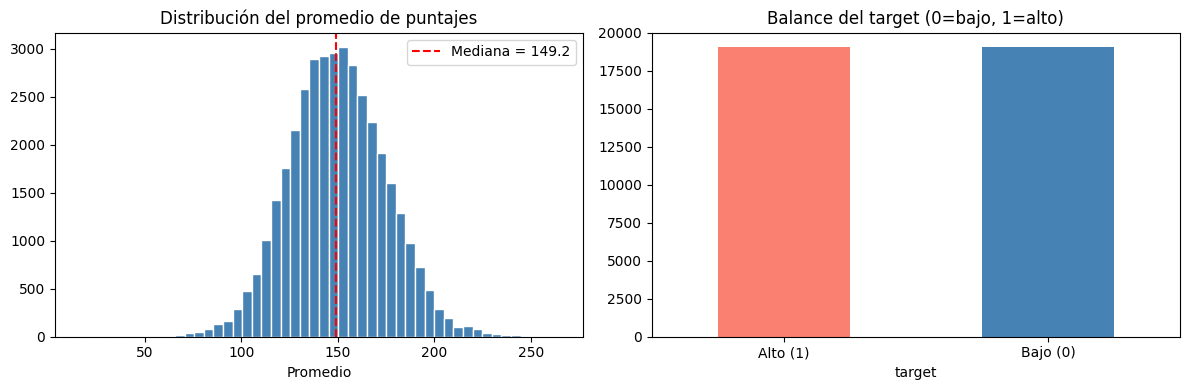

C:\Users\Dante_RT\AppData\Local\Temp\ipykernel_39572\260611858.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="fami_estratovivienda", y=col,
C:\Users\Dante_RT\AppData\Local\Temp\ipykernel_39572\260611858.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="fami_estratovivienda", y=col,
C:\Users\Dante_RT\AppData\Local\Temp\ipykernel_39572\260611858.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="fami_estratovivienda", y=col,
C:\Users\Dante_RT\AppData\Local\Temp\ipykernel_39572\26061185

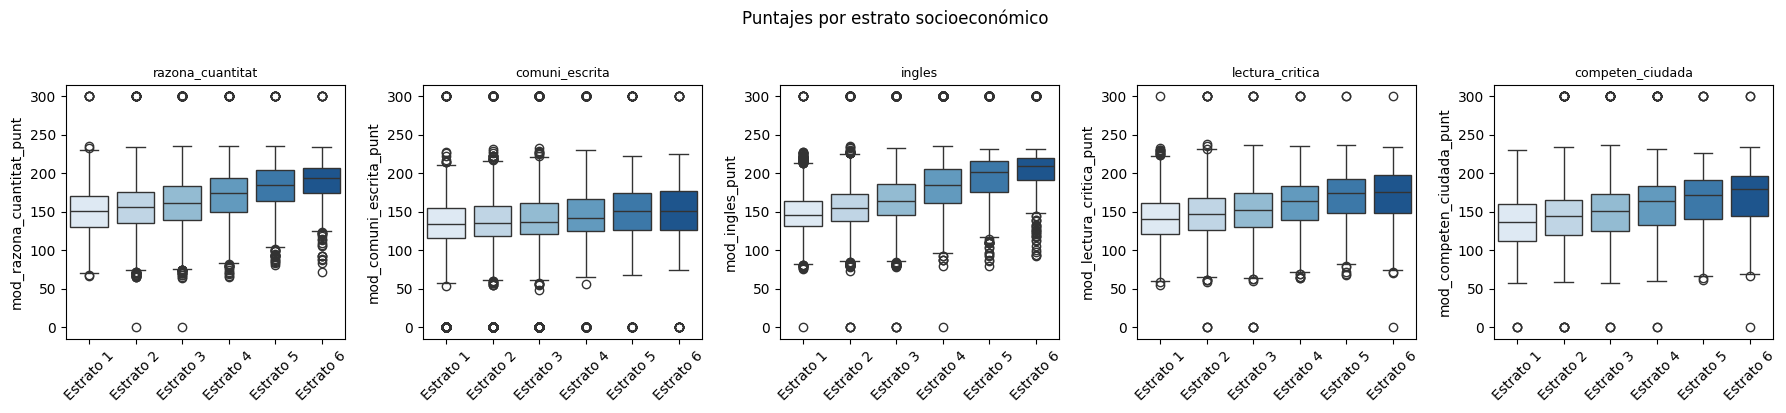

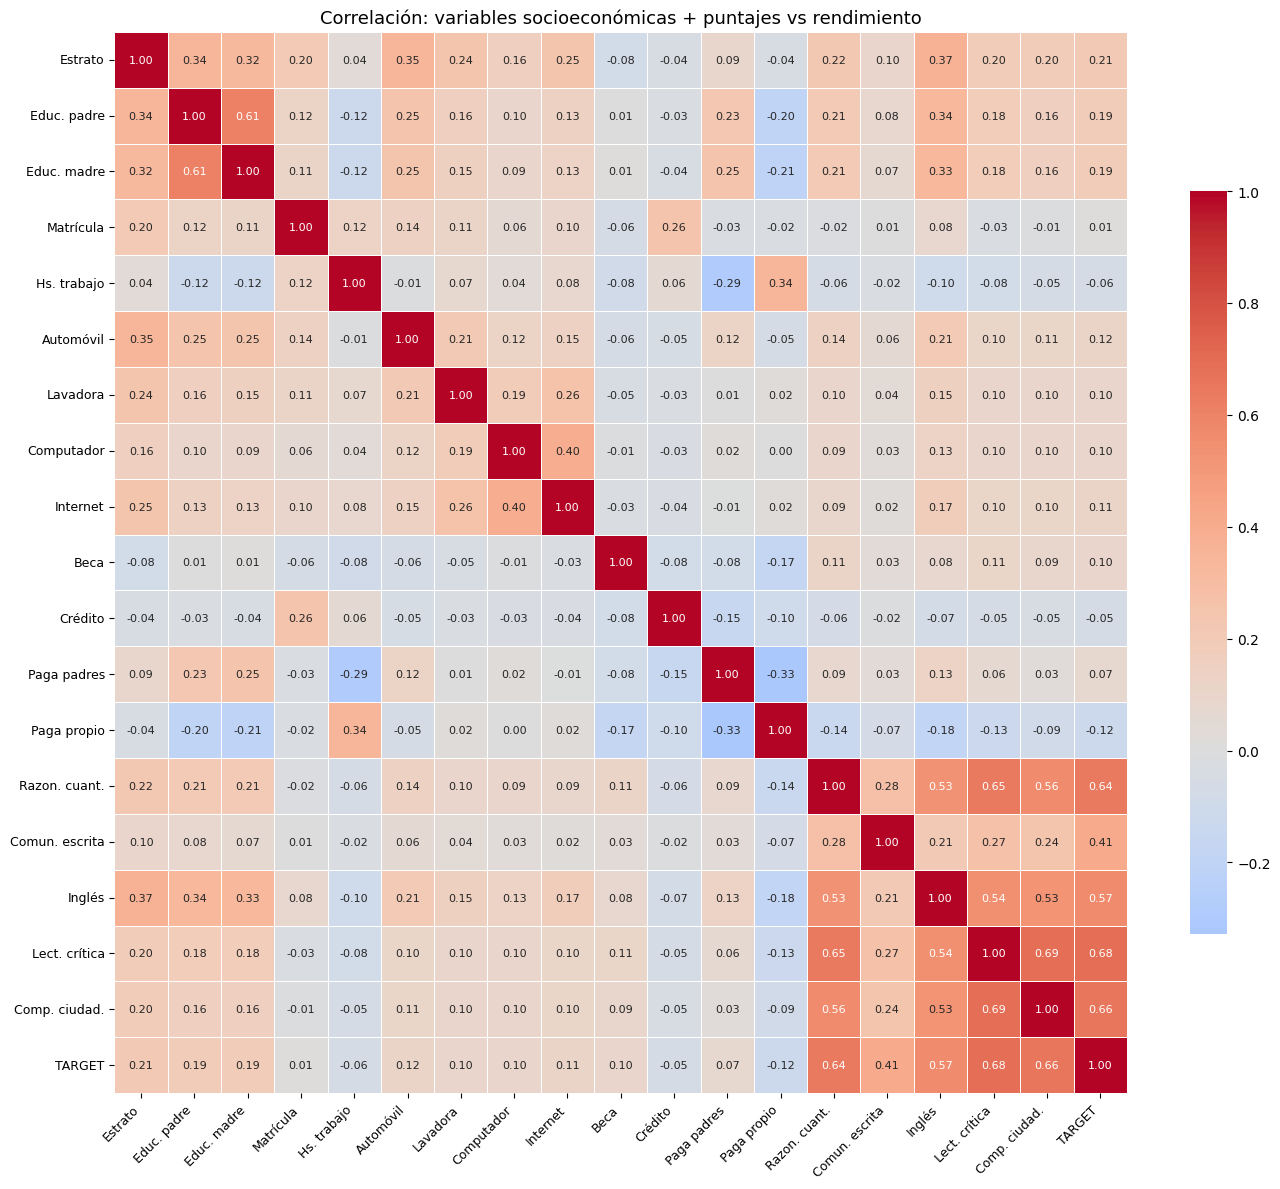

Columnas con nulos en df_model:
 educ_padre_num                   2711
matricula_num                    2506
fami_tieneautomovil_bin          1664
fami_tienelavadora_bin           1479
fami_tienecomputador_bin         1432
estrato_num                      1358
educ_madre_num                   1309
horas_trabajo_num                1301
fami_tieneinternet_bin           1129
estu_pagomatriculacredito_bin     306
estu_pagomatriculabeca_bin        303
estu_pagomatriculapadres_bin      303
estu_pagomatriculapropio_bin      302
ingles_desem_num                    5
estu_genero_bin                     4
dtype: int64


In [10]:
# Gráfica 1: Distribución del promedio y balance del target
# Estas sí usan df_clean porque promedio_puntaje y target
# se crearon antes del encoding (en la celda 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_model["promedio_puntaje"].dropna(), bins=50,
             color="steelblue", edgecolor="white")
axes[0].axvline(mediana, color="red", linestyle="--",
                label=f"Mediana = {mediana:.1f}")
axes[0].set_title("Distribución del promedio de puntajes")
axes[0].set_xlabel("Promedio")
axes[0].legend()

df_model["target"].value_counts().plot(
    kind="bar", ax=axes[1], color=["salmon", "steelblue"])
axes[1].set_title("Balance del target (0=bajo, 1=alto)")
axes[1].set_xticklabels(["Alto (1)", "Bajo (0)"], rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/dist_target.png", dpi=150)
plt.show()

# Gráfica 2: Boxplots puntajes por estrato
# Ahora usamos df_model que tiene fami_estratovivienda aún como texto
# (la columna original no se toca, solo creamos estrato_num nueva)
fig, axes = plt.subplots(1, len(score_cols), figsize=(18, 4), sharey=False)
orden_estrato = ["Estrato 1","Estrato 2","Estrato 3",
                 "Estrato 4","Estrato 5","Estrato 6"]

for ax, col in zip(axes, score_cols):
    subset = df_model[df_model["fami_estratovivienda"].isin(orden_estrato)]
    sns.boxplot(data=subset, x="fami_estratovivienda", y=col,
                order=orden_estrato, ax=ax, palette="Blues")
    ax.set_title(col.replace("mod_","").replace("_punt",""), fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Puntajes por estrato socioeconómico", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/boxplots_estrato.png", dpi=150)
plt.show()

# Gráfica 3: Heatmap COMPLETO con variables SE numerizadas
# Ahora sí podemos incluir estrato_num, educ_padre_num, etc.
# porque ya existen en df_model gracias a la celda 4
cols_heatmap = [
    "estrato_num", "educ_padre_num", "educ_madre_num",
    "matricula_num", "horas_trabajo_num",
    "fami_tieneautomovil_bin", "fami_tienelavadora_bin",
    "fami_tienecomputador_bin", "fami_tieneinternet_bin",
    "estu_pagomatriculabeca_bin", "estu_pagomatriculacredito_bin",
    "estu_pagomatriculapadres_bin", "estu_pagomatriculapropio_bin",
    "mod_razona_cuantitat_punt", "mod_comuni_escrita_punt",
    "mod_ingles_punt", "mod_lectura_critica_punt",
    "mod_competen_ciudada_punt",
    "target"
]
cols_heatmap = [c for c in cols_heatmap if c in df_model.columns]

# Nombres cortos para que quepan en la figura
nombres_cortos = {
    "estrato_num": "Estrato",
    "educ_padre_num": "Educ. padre",
    "educ_madre_num": "Educ. madre",
    "matricula_num": "Matrícula",
    "horas_trabajo_num": "Hs. trabajo",
    "fami_tieneautomovil_bin": "Automóvil",
    "fami_tienelavadora_bin": "Lavadora",
    "fami_tienecomputador_bin": "Computador",
    "fami_tieneinternet_bin": "Internet",
    "estu_pagomatriculabeca_bin": "Beca",
    "estu_pagomatriculacredito_bin": "Crédito",
    "estu_pagomatriculapadres_bin": "Paga padres",
    "estu_pagomatriculapropio_bin": "Paga propio",
    "mod_razona_cuantitat_punt": "Razon. cuant.",
    "mod_comuni_escrita_punt": "Comun. escrita",
    "mod_ingles_punt": "Inglés",
    "mod_lectura_critica_punt": "Lect. crítica",
    "mod_competen_ciudada_punt": "Comp. ciudad.",
    "target": "TARGET"
}

corr = df_model[cols_heatmap].corr()
corr.columns = [nombres_cortos.get(c, c) for c in corr.columns]
corr.index   = [nombres_cortos.get(c, c) for c in corr.index]

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.4,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 8}
)
plt.title("Correlación: variables socioeconómicas + puntajes vs rendimiento",
          fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/heatmap_completo.png", dpi=150)
plt.show()

# ── Nulos restantes ───────────────────────────────────────────────────────────
nulos = df_model.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Columnas con nulos en df_model:\n", nulos)

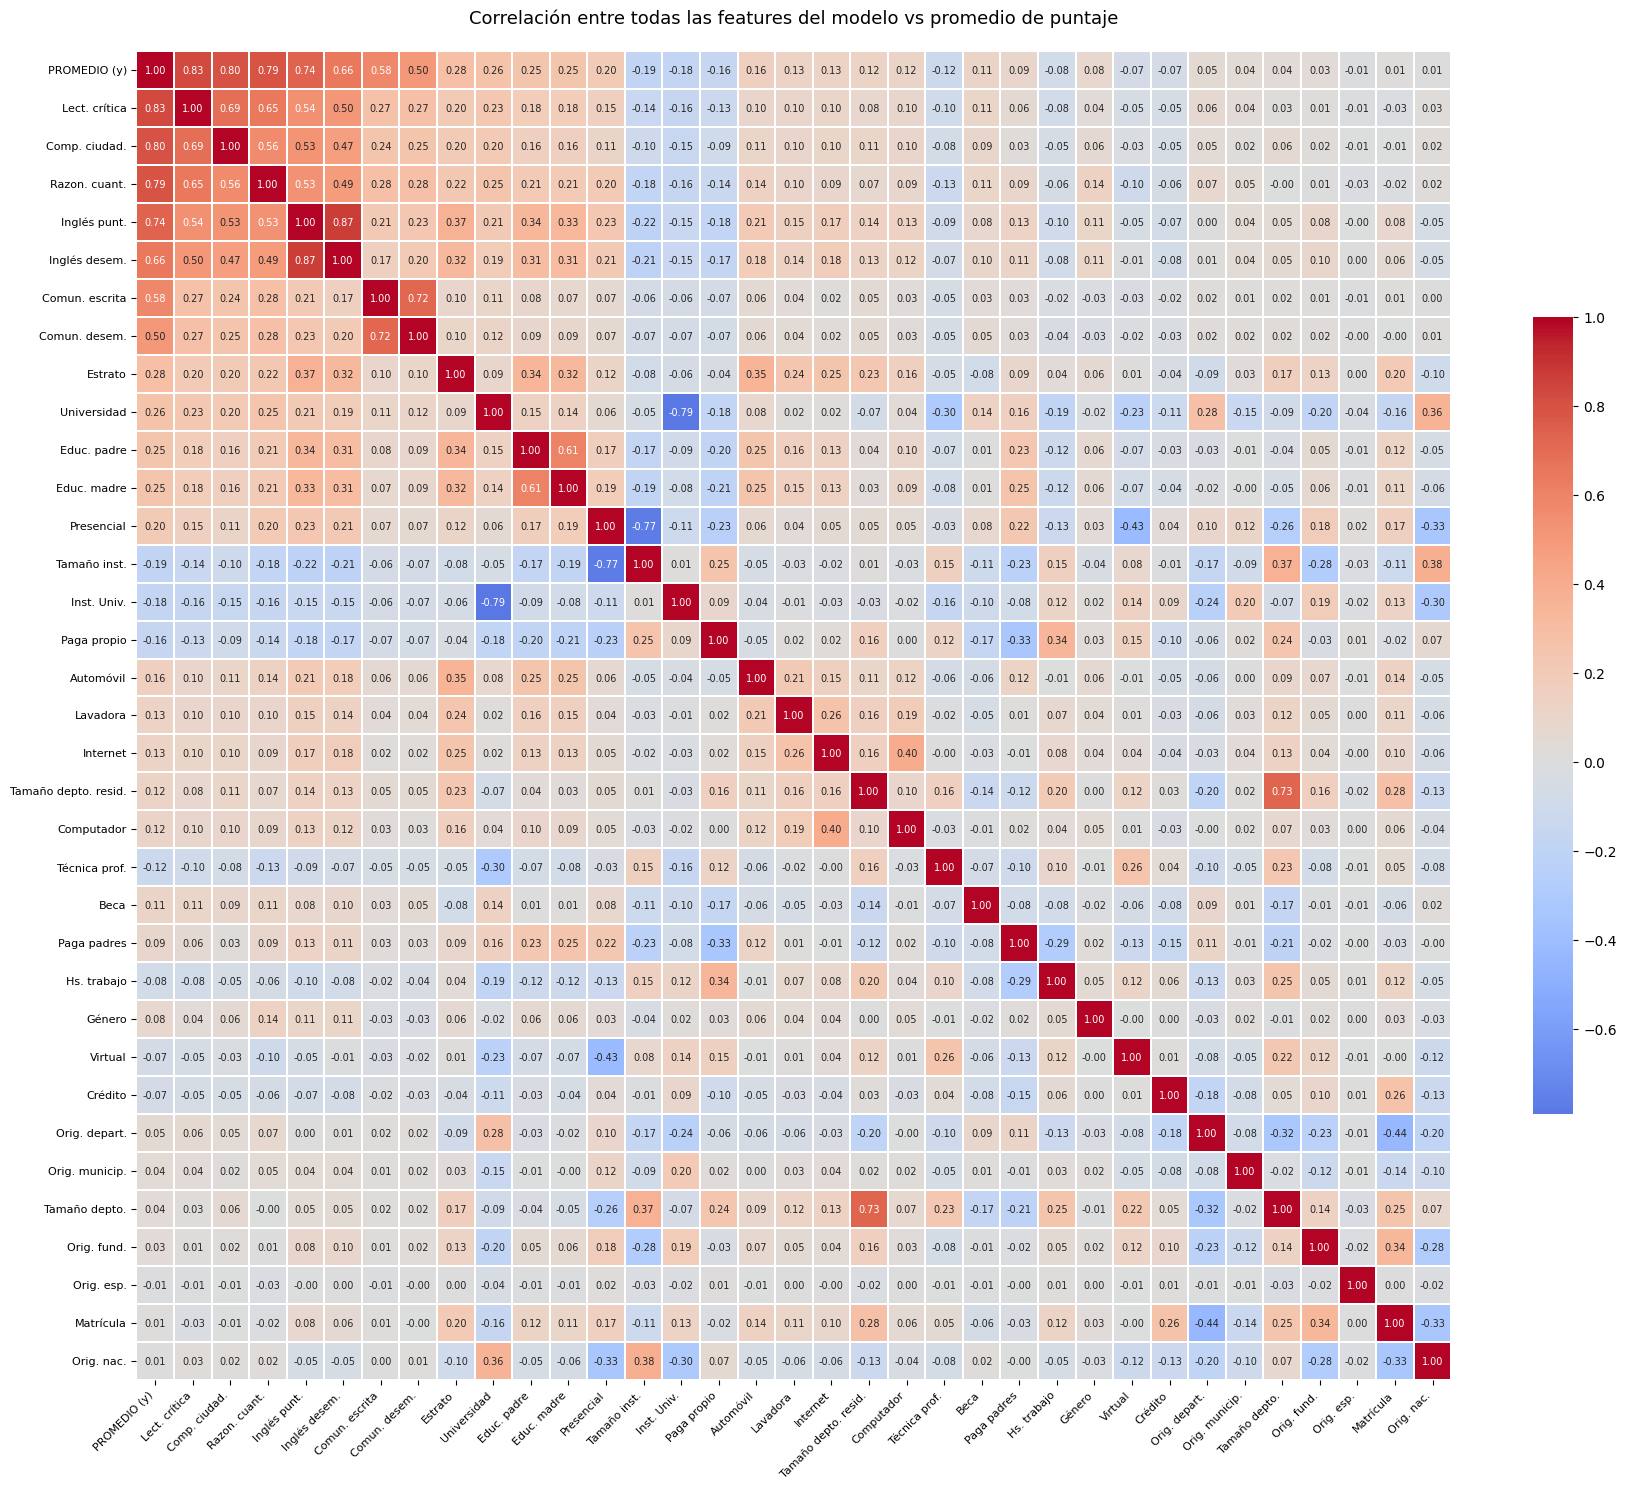


Ranking de correlación con PROMEDIO DE PUNTAJE:
─────────────────────────────────────────────
  +0.825  mod_lectura_critica_punt
  +0.800  mod_competen_ciudada_punt
  +0.793  mod_razona_cuantitat_punt
  +0.738  mod_ingles_punt
  +0.655  ingles_desem_num
  +0.580  mod_comuni_escrita_punt
  +0.497  comunica_desem_num
  +0.281  estrato_num
  +0.265  inst_caracter_academico_UNIVERSIDAD
  +0.251  educ_padre_num
  +0.247  educ_madre_num
  +0.200  estu_metodo_prgm_PRESENCIAL
  -0.186  inst_nombre_institucion_freq
  -0.176  inst_caracter_academico_INSTITUCIÓN UNIVERSITARIA
  -0.159  estu_pagomatriculapropio_bin
  +0.159  fami_tieneautomovil_bin
  +0.128  fami_tienelavadora_bin
  +0.127  fami_tieneinternet_bin
  +0.119  estu_depto_reside_freq
  +0.118  fami_tienecomputador_bin
  -0.115  inst_caracter_academico_TÉCNICA PROFESIONAL
  +0.111  estu_pagomatriculabeca_bin
  +0.088  estu_pagomatriculapadres_bin
  -0.082  horas_trabajo_num
  +0.081  estu_genero_bin
  -0.069  estu_metodo_prgm_DISTANCIA

: 

In [ ]:
# ── Heatmap COMPLETO con todas las features del modelo ────────────────────────
# Usamos X directamente porque ya tiene exactamente las columnas
# que entran al modelo, todas numéricas y limpias
# Agregamos promedio_puntaje como variable objetivo (regresión)

cols_heatmap = feature_cols + ["promedio_puntaje"]
# feature_cols → lista que ya construiste en el paso 7
# contiene TODAS las columnas numerizadas: _num, _bin, _freq, one-hot, puntajes
# + promedio_puntaje → es el y que ahora predecimos (reemplaza a target)

cols_heatmap = [c for c in cols_heatmap if c in df_model.columns]
# filtro de seguridad: solo columnas que existen en df_model

corr = df_model[cols_heatmap].corr()
# calcula correlación de Pearson entre todas las columnas
# resultado: matriz de ~35x35

# Nombres cortos para que quepan en la figura
nombres_cortos = {
    "estrato_num": "Estrato",
    "educ_padre_num": "Educ. padre",
    "educ_madre_num": "Educ. madre",
    "matricula_num": "Matrícula",
    "horas_trabajo_num": "Hs. trabajo",
    "ingles_desem_num": "Inglés desem.",
    "comunica_desem_num": "Comun. desem.",
    "fami_tieneautomovil_bin": "Automóvil",
    "fami_tienelavadora_bin": "Lavadora",
    "fami_tienecomputador_bin": "Computador",
    "fami_tieneinternet_bin": "Internet",
    "estu_pagomatriculabeca_bin": "Beca",
    "estu_pagomatriculacredito_bin": "Crédito",
    "estu_pagomatriculapadres_bin": "Paga padres",
    "estu_pagomatriculapropio_bin": "Paga propio",
    "estu_genero_bin": "Género",
    "inst_nombre_institucion_freq": "Tamaño inst.",
    "estu_prgm_departamento_freq": "Tamaño depto.",
    "estu_depto_reside_freq": "Tamaño depto. resid.",
    "inst_caracter_academico_INSTITUCIÓN UNIVERSITARIA": "Inst. Univ.",
    "inst_caracter_academico_TÉCNICA PROFESIONAL": "Técnica prof.",
    "inst_caracter_academico_UNIVERSIDAD": "Universidad",
    "inst_origen_NO OFICIAL - FUNDACIÓN": "Orig. fund.",
    "inst_origen_OFICIAL DEPARTAMENTAL": "Orig. depart.",
    "inst_origen_OFICIAL MUNICIPAL": "Orig. municip.",
    "inst_origen_OFICIAL NACIONAL": "Orig. nac.",
    "inst_origen_REGIMEN ESPECIAL": "Orig. esp.",
    "estu_metodo_prgm_DISTANCIA VITUAL": "Virtual",
    "estu_metodo_prgm_PRESENCIAL": "Presencial",
    "mod_razona_cuantitat_punt": "Razon. cuant.",
    "mod_comuni_escrita_punt": "Comun. escrita",
    "mod_ingles_punt": "Inglés punt.",
    "mod_lectura_critica_punt": "Lect. crítica",
    "mod_competen_ciudada_punt": "Comp. ciudad.",
    "promedio_puntaje": "PROMEDIO (y)",
    # target lo dejamos por si queremos analizarlo también
    "target": "TARGET",
}

corr.columns = [nombres_cortos.get(c, c) for c in corr.columns]
# recorre cada nombre de columna en corr.columns
# si está en nombres_cortos → usa el nombre corto
# si no está → deja el nombre original

corr.index = [nombres_cortos.get(c, c) for c in corr.index]
# lo mismo para las filas (el heatmap tiene el mismo nombre en filas y columnas)

# Ordenar por correlación con el promedio (la última columna)
# así las variables más relacionadas con el rendimiento quedan arriba
orden = corr["PROMEDIO (y)"].abs().sort_values(ascending=False).index
# .abs() → valor absoluto (correlación negativa fuerte también es importante)
# .sort_values(ascending=False) → de mayor a menor correlación con el promedio
# .index → obtiene el orden de los nombres

corr = corr.loc[orden, orden]
# reordena filas y columnas según ese orden
# así la variable más correlacionada con el promedio queda arriba a la izquierda

plt.figure(figsize=(18, 15))
# figura grande porque tenemos ~35 variables

sns.heatmap(
    corr,
    annot=True,           # muestra el número dentro de cada celda
    fmt=".2f",            # con 2 decimales
    cmap="coolwarm",      # azul = correlación negativa, rojo = positiva
    center=0,             # blanco = correlación 0
    linewidths=0.3,       # líneas finas entre celdas
    cbar_kws={"shrink": 0.6},   # barra de color más pequeña
    annot_kws={"size": 7}       # texto dentro de celdas más pequeño para que quepan
)

plt.title("Correlación entre todas las features del modelo vs promedio de puntaje",
          fontsize=13, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=8)
# rotation=45 → etiquetas en diagonal para que no se encimen
# ha="right" → alineadas a la derecha del punto de rotación

plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/figures/heatmap_completo.png", dpi=150, bbox_inches="tight")
# bbox_inches="tight" → no corta las etiquetas en los bordes
plt.show()

# ── Imprimir ranking de correlación con el promedio ───────────────────────────
print("\nRanking de correlación con PROMEDIO DE PUNTAJE:")
ranking = df_model[cols_heatmap].corr()["promedio_puntaje"].abs()
# corr()["promedio_puntaje"] → solo la columna del promedio de la matriz
# .abs() → valor absoluto para ordenar independiente del signo

ranking = ranking.drop("promedio_puntaje")
# elimina la autocorrelación (promedio consigo mismo = 1.0)

ranking = ranking.sort_values(ascending=False)
# ordena de mayor a menor correlación

for nombre, valor in ranking.items():
    signo = "+" if df_model[cols_heatmap].corr()["promedio_puntaje"][nombre] > 0 else "-"
    # signo → muestra si la correlación es positiva o negativa
    # + significa que a mayor valor de esa variable, mayor puntaje
    # - significa que a mayor valor, menor puntaje
    print(f"  {signo}{valor:.3f}  {nombre}")